---
title: "Heston Model Calibration"
description: "Stochastic volatility calibration using numerical optimization and Monte Carlo methods."
image: ../img/heston.png
author: "Franck Deba"
date: 2024-01-01
---

In [1]:
from heston import*
import numpy as np
import pandas as pd

Ce travail présente une comparaison des filtres Bootstrap et APF utilisés pour la calibration du processus de volatilité d'un modèle d'Heston. Nous partons de données (prix de call et du soujacent) simulées à partir d'un schéma de discrétisation modifié du modèle. Les performances des différents filtres sont évaluées sur la base la moyenne des erreurs quadratiques (MSE), ceteris paridus. L'application des trois filtres étudiés montre que le filtre APF est meilleur que le filtre Bootstrap pour un nombre faible de particules. Ces performances se raprochent Bienque ces MSE soient assez prochent, on peut tout de même noté que le filtre APF est moins performant que ce à quoi on se serait attendu, étant donné qu'il est une modification du filtre Bootstrap visant à corrigé les errurs éventuelles de ce dernier.

# Introduction

Le modèle d'Heston fait partie des trois modèles stochastiques usuels admettant une formule ferme avec le processus d'Ornstein-Uhlenbeck et le processus de Black-Scholes. C'est un modèle à volatilité stochastique. De nombreuses approches sont développées dans la littérature pour calibrer le processus de volatilité implicite, dont notamment les filtres de Bootstrap et des variantes du filtre de Kalman. Nous nous intéressons en particulier au filtre de Kalman étendu (EKF) et au filtre à particules auxiliaires (APF). Une première difficulté à laquelle il faut faire face réside dans la simulation des données à partir du modèle d'Heston de base. Une solution consiste généralement à utiliser un schéma de discrétisation d'Euler. Cependant, on se rend vite compte que des volatilités négatives sont susceptibles d'émerger, ce qui est en soi incompatible avec la définition. On recourt à une modification du schéma de discrétisation pour rentrer dans un domaine de valeurs cohérentes. Le but de ce papier est de présenter une comparaison des performances des filtres APF, EKF et bootstrap sur le modèle d'Heston.

# Quelques résultats préliminaires

Soit $Z$ une v.a gaussienne de moyenne $\mu$ et de variance $\sigma^2$.



La densité de  $|Z|$ est donnée par: 
    $$
    f_Z(x) = \frac{1}{\sigma \sqrt{2\pi} } \left( \exp\left(-\frac{(x-\mu)^2}{2\sigma^2} \right) + \exp\left(-\frac{(x+\mu)^2}{2\sigma^2} \right) \right) \mathbb{1}_{x \geq 0}.
    $$
De plus,
$$
    E(|Z|) = \sigma \sqrt{\dfrac{2}{\pi}} \exp{\left(-\dfrac{\mu^2}{2\sigma^2}\right)} + \mu \left(1-2\Phi(-\dfrac{\mu}{\sigma})\right)
$$

où $\Phi$ est la fonctioon de répartition de la gaussienne standard.



# Le modèle d'Heston

Le modèle d'Heston est donné par:

\begin{equation}
    \begin{cases}
        dS_t = S_t(rdt + \sqrt{v_t}dW_{t}^1) \\
        dv_t = \lambda(\bar{v}-v_t)dt + \eta \sqrt{v_t}dW_{t}^2 \\
        dW_{t}^1.dW_{t}^2 = \rho dt
    \end{cases}
\end{equation}

ù $W_t^1$ et $W_t^2$ sont deux mouvements browniens et $r$ est le taux sans risque. Pour ce modèle, les rendements sont modélisés par un mouvement brownien géométrique avec une variance stochastique. La variance non observée $v_t$ est déterminée par un processus stochastique de retour à la moyenne, qui a été introduit en 1985 par Cox, Ingersoll et Ross pour la modélisation des taux d’intérêt à court terme. Le paramètre $\lambda$ est le paramètre de retour à la moyenne positive, $\bar{v}$ est le paramètre positif à long terme et $\eta$ est la volatilité positive du paramètre de variance. De plus, Heston a introduit une corrélation entre les deux mouvements browniens $W_t^1$ et $W_t^2$, représentée par le paramètre $\rho$ compris entre $-1$ et 1.

## Modèle d'Heston discrétisé

On souhaite désormais calibrer la volatilité sous le modèle d’Heston à partir de prix d’options. Pour cela, nous considérons la version discrétisée par un schéma d’Euler (modifié) de (1). Plus
précisément, soit

\begin{equation}
    \begin{cases}
        y_t = C(t, \theta, v_t, S_t, k, \tau) + \sigma_{\epsilon}\epsilon_t \\
        S_t = S_{t-1}(1+r\Delta + \sqrt{\Delta v_{t-1}}Z_{t}^1) \\
        v_t = |v_{t-1} + \lambda \Delta(\bar{v}-v_{t-1}) + \eta \sqrt{\Delta v_{t-1}}Z_{t}^2| \\
        Cov(Z_t^1,Z_t^2) = \rho
    \end{cases}
\end{equation}
\label{Heston_Discrete}

avec la notation $|.|$ pour la valeur absolue et $(Z_t^j)_{t=1,...,n}$ des v.a. gaussiennes centrées et réduites $j = 1, 2$. $\Delta$ correspond au pas de discrétisation $(\Delta = \dfrac{\tau}{n})$ où $n$ est le nombre de points d’observations et $(\epsilon_t)_{t=1,...,n}$ correspond à des bruits de mesure supposés gaussiens i.i.d et de variance $\sigma_{\epsilon}^2$. Le processus $(y_t)_{t=1,...,n} $ correspond aux observations, ici journalières. Ainsi, nous supposons que nous disposons chaque jour du prix d’un Call noté $y_t$ de strike $K$ et de maturité $\tau$ indexé sur un sous-jacent $S_t$. Ce prix contient des erreurs de mesure notées $\epsilon_t$. Les observations du sous-jacent sont également disponibles chaque jour et nous souhaitons mettre en place une méthode de filtrage pour retrouver la trajectoire de la volatilité $(v_t)_{t=1,...,n}$.

## Loi de transition d'états

Le processus de particules $(v_t)_t$ décrit dans l'équation \ref{Heston_Discrete} est une chaîne de Markov non homogène de loi de transition $p(v_t|v_{t-1})$ où $v_t|v_{t-1} \sim |\mathcal{N}(m_t, \sigma_t)|$.


$$
E(v_t|v_{t-1}) = \sigma_t \sqrt{\dfrac{2}{\pi}} \exp{\left(-\dfrac{m_t^2}{2\sigma_t^2}\right)} + m_t \left(1-2\Phi(-\dfrac{m_t}{\sigma_t})\right)
$$ 
avec
$m_t = v_{t-1} + \lambda \Delta(\bar{v}-v_{t-1})$  et  $\sigma_t = \eta \sqrt{\Delta v_{t-1}}$

où $\Phi$ est la fonction de répartition de la gaussienne standard.


# Mise en oeuvre
## Simulation des données

Pour des besoins de reproductibilité, une graine est fixé à 90 sous python.
Nous simulons $(y_t)_{t=1,...,n} $ et $(S_t)_{t=1,...,n}$ à partir de l'équation \ref{Heston_Discrete} en considérant le paramètre $\theta = (\lambda,\eta,\bar{v},\rho)=(4,0.4,0.03,-0.5)$, $\sigma_{\epsilon}^2 = 0.1$, une maturité $\tau = 1$ et un strike $K = 100$. 
Dans un second temps nous simulerons des prix de call avec plusieurs strikes de manière adaptative pour trois cas de figure (TAM, ITM et OTM). Cette démarche a pour but de prendre en compte diverses informations pour la calibration de la vol. De plus la liquidité de ces différents instruments est pris en compte dans la matrice de covariance associée.

In [2]:
import numpy as np
from scipy.optimize import broyden1
from scipy.stats import norm, gamma


def heston(stock_price, initial_vol, kappa, theta, lambd, rho, r, T, K):
    """
    Compute the option price using the Heston model.

    Parameters:
        kappa: Mean reversion speed.
        theta: Long-term variance.
        lambd: Volatility of volatility.
        T: Time to maturity.
        K: Strike price.

    Returns:
        Option price.
    """
    # Initial values
    V0 = initial_vol
    X0 = stock_price
    I = 1j  # Imaginary unit
    P, umax, N = 0, 1000, 10000
    du = umax / N

    aa = theta * kappa * T / lambd**2
    bb = -2 * theta * kappa / lambd**2

    for i in range(1, N):
        u2 = i * du
        u1 = u2 - 1j  # Complex number

        a1 = rho * lambd * u1 * I
        a2 = rho * lambd * u2 * I

        d1 = np.sqrt((a1 - kappa)**2 + lambd**2 * (u1 * I + u1**2))
        d2 = np.sqrt((a2 - kappa)**2 + lambd**2 * (u2 * I + u2**2))

        g1 = (kappa - a1 - d1) / (kappa - a1 + d1)
        g2 = (kappa - a2 - d2) / (kappa - a2 + d2)

        b1 = np.exp(u1 * I * (np.log(X0 / K) + r * T)) * ((1 - g1 * np.exp(-d1 * T)) / (1 - g1))**bb
        b2 = np.exp(u2 * I * (np.log(X0 / K) + r * T)) * ((1 - g2 * np.exp(-d2 * T)) / (1 - g2))**bb

        phi1 = b1 * np.exp(aa * (kappa - a1 - d1) + V0 * (kappa - a1 - d1) * (1 - np.exp(-d1 * T)) / (1 - g1 * np.exp(-d1 * T)) / lambd**2)
        phi2 = b2 * np.exp(aa * (kappa - a2 - d2) + V0 * (kappa - a2 - d2) * (1 - np.exp(-d2 * T)) / (1 - g2 * np.exp(-d2 * T)) / lambd**2)

        P += ((phi1 - phi2) / (u2 * I)) * du

    return K * np.real((X0 / K - np.exp(-r * T)) / 2 + P / np.pi)


def resample_particles(particles, weights):
    """
    Resample particles according to their weights.

    Parameters:
        particles: List or array of particles (state trajectories).
        weights: List or array of particle weights.

    Returns:
        resampled_particles: Resampled particles.
        resampled_indices: Indices of the resampled particles.
        resampled_weights: Uniform weights (1/M) for the resampled particles.
    """
    M = len(particles)  # Number of particles

    # Normalize weights
    weights = np.array(weights) / np.sum(weights)

    # Compute cumulative weights
    cumulative_weights = np.cumsum(weights)

    # Generate M uniform random variables
    U = np.random.uniform(0, 1, M)

    # Resample particles
    resampled_particles = []
    resampled_indices = []
    for j in range(M):
        # Find the smallest i such that U[j] < cumulative_weights[i]
        i = np.searchsorted(cumulative_weights, U[j], side='right')
        resampled_particles.append(particles[i])
        resampled_indices.append(i)

    # Reset weights to 1/M
    resampled_weights = np.ones(M) / M

    return resampled_particles, resampled_indices, resampled_weights



def Bootstrap_Heston(C, S, K, tau, r, lamda, v_bar, rho, sigma, eta, M=100):
    
    n = len(C)  # Longueur de l'échantillon
    delta = tau/n
    
    # Etape 1: Initialisation des particules et des poids
    shape= (2*lamda*v_bar) / (eta**2)
    scale= (eta**2) / (2*lamda)
    v = np.random.gamma(shape, scale = scale, size=M) # Particules initiales
    weights = gamma.pdf(v, shape, scale)
    weights /= np.sum(weights)

    v_t = []
    for t in range(n):
        for i in range(M):
            mu = v[i] + lamda * delta * (v_bar - v[i])
            sig =  eta * np.sqrt(v[i]*delta)
            v[i] = np.abs(np.random.normal(mu, sig))
            C_t = heston(stock_price = S[t],
                         initial_vol = v[i],
                         kappa = lamda,
                         theta = v_bar, 
                         lambd = eta, 
                         rho = rho, 
                         r = r, 
                         T = tau,
                         K = K)
            weights[i] = norm.pdf(C[t], loc = C_t, scale = np.sqrt(sigma))
        weights /= np.sum(weights)
    
        resampled_particles, resampled_indices, resampled_weights = resample_particles(v, weights)
        weights = resampled_weights
        v = resampled_particles
        v_t.append(np.mean(v))
    return np.array(v_t)


def APF(C, S, K, tau, r, lamda, v_bar, rho, sigma, eta, M=100):
    
    n = len(C)  # Longueur de l'échantillon
    delta = tau/n

    # Etape 1: Initialisation des particules et des poids
    shape= (2*lamda*v_bar) / (eta**2)
    scale= (eta**2) / (2*lamda)
    x_particles = np.random.gamma(shape, scale = scale, size=M) # Particules initiales

    weights = np.ones(M) / M # Poids initiaux

    v_t = []
    for t in range(n):

        # Etape 2:
        p_mu_t = []
        for i in range(M):
            mu = x_particles[i] + lamda * delta * (v_bar - x_particles[i])
            sig =  eta * np.sqrt(x_particles[i]*delta)
            mu_t = sig * np.sqrt(2/np.pi) * np.exp(-0.5*(mu/sig)**2) + mu * (1-2*norm.cdf(-mu/sig))
        
            C_t = heston(stock_price = S[t],
                         initial_vol = mu_t,
                         kappa = lamda,
                         theta = v_bar, 
                         lambd = eta, 
                         rho = rho, 
                         r = r, 
                         T = tau,
                         K = K)
            p_mu_t.append(norm.pdf(C[t], loc = C_t, scale = sigma**0.5))
            weights[i] = weights[i] * p_mu_t[i]
            

        # Etape 3:
        resampled_particles, resampled_indices, resampled_weights = resample_particles(x_particles, weights)

        
        # Etape 4: Propagation
        for i in range(M):
            mu = resampled_particles[i] + lamda * delta * (v_bar - resampled_particles[i])
            sig =  eta * np.sqrt(resampled_particles[i]*delta)
            x_particles[i] = np.abs(np.random.normal(mu, sig))
            
            C_t_num = heston(stock_price = S[t],
                         initial_vol = x_particles[i],
                         kappa = lamda,
                         theta = v_bar, 
                         lambd = eta, 
                         rho = rho, 
                         r = r, 
                         T = tau,
                         K = K)
    
            # Etape 5 Update weights
            weights[i] = norm.pdf(C[t], C_t_num, np.sqrt(sigma)) /p_mu_t[resampled_indices[i]]
        # Normalize weights
        weights /= np.sum(weights)
        v_t.append(np.mean(x_particles))
    return np.array(v_t)

# APF Modified
def APF_modified(C, S, K, tau, r, lamda, v_bar, rho, sigma, eta, M=100):
    
    n = len(C)  # Longueur de l'échantillon
    delta = tau/n

    # Etape 1: Initialisation des particules et des poids
    shape= (2*lamda*v_bar) / (eta**2)
    scale= (eta**2) / (2*lamda)
    x_particles = np.random.gamma(shape, scale = scale, size=M) # Particules initiales

    weights = np.ones(M) / M # Poids initiaux

    v_t = []
    for t in range(n):

        # Etape 2:
        p_mu_t = []
        for i in range(M):
            mu = x_particles[i] + lamda * delta * (v_bar - x_particles[i])
            #sig =  eta * np.sqrt(x_particles[i]*delta)
            #mu_t = sig * np.sqrt(2/np.pi) * np.exp(-0.5*(mu/sig)**2) + mu * (1-2*norm.cdf(-mu/sig))
            mu_t = np.abs(mu)#
            C_t = heston(stock_price = S[t],
                         initial_vol = mu_t,
                         kappa = lamda,
                         theta = v_bar, 
                         lambd = eta, 
                         rho = rho, 
                         r = r, 
                         T = tau,
                         K = K)
            p_mu_t.append(norm.pdf(C[t], loc = C_t, scale = np.sqrt(sigma)))
            weights[i] = weights[i] * p_mu_t[i]
            

        # Etape 3:
        resampled_particles, resampled_indices, resampled_weights = resample_particles(x_particles, weights)

        
        # Etape 4: Propagation
        for i in range(M):
            mu = resampled_particles[i] + lamda * delta * (v_bar - resampled_particles[i])
            sig =  eta * np.sqrt(resampled_particles[i]*delta)
            x_particles[i] = np.abs(np.random.normal(mu, sig))
            
            C_t_num = heston(stock_price = S[t],
                         initial_vol = x_particles[i],
                         kappa = lamda,
                         theta = v_bar, 
                         lambd = eta, 
                         rho = rho, 
                         r = r, 
                         T = tau,
                         K = K)
    
            # Etape 5 Update weights
            weights[i] = norm.pdf(C[t], C_t_num, np.sqrt(sigma)) /p_mu_t[resampled_indices[i]]
        # Normalize weights
        weights /= np.sum(weights)
        v_t.append(np.mean(x_particles))
    return np.array(v_t)


def SimHeston(S0, K, tau, r, lamda, v_bar, rho, sigma, eta, size = 252):
    delta = tau/size
    S = [S0]
    v = [v_bar]
    C = [heston(stock_price = S0,
                         initial_vol = v_bar,
                         kappa = lamda,
                         theta = v_bar, 
                         lambd = eta, 
                         rho = rho, 
                         r = r, 
                         T = tau,
                         K = K)]
    for t in range(1,size):
        Z = np.random.multivariate_normal(np.array([0,0]),
                                         np.array([[1,rho],[rho,1]]))
        mu = v[t-1] + lamda * delta * (v_bar - v[t-1])
        sig =  eta * np.sqrt(v[t-1]*delta)
        v.append(np.abs(mu + sig*Z[0]))
        S.append(S[t-1]*(1 + r * delta + np.sqrt(delta*v[t-1])*Z[1]))
        C.append(heston(stock_price = S[t],
                         initial_vol = v[t],
                         kappa = lamda,
                         theta = v_bar, 
                         lambd = eta, 
                         rho = rho, 
                         r = r, 
                         T = tau,
                         K = K) + np.sqrt(sigma)*np.random.normal(0,1))
    return S, C, v

In [3]:
import matplotlib.pyplot as plt
def plot_data(data, labels = ["Simulated Returns"], title=""):
    
    # Plotting the simulated return
    plt.figure(figsize=(10, 4))
    for df, label in zip(data, labels):
        plt.plot(df, label=label)
    plt.title(title)
    plt.legend()
    plt.show()

In [4]:
S0 = 100
K = 100
tau = 1
lamda = 4
v_bar = 0.03
rho = -0.5
sigma = 0.1
eta = 0.4
r = 0.05

np.random.seed(90)
S, C, v = SimHeston(S0, K, tau, r, lamda, v_bar, rho, sigma, eta, size = 252)

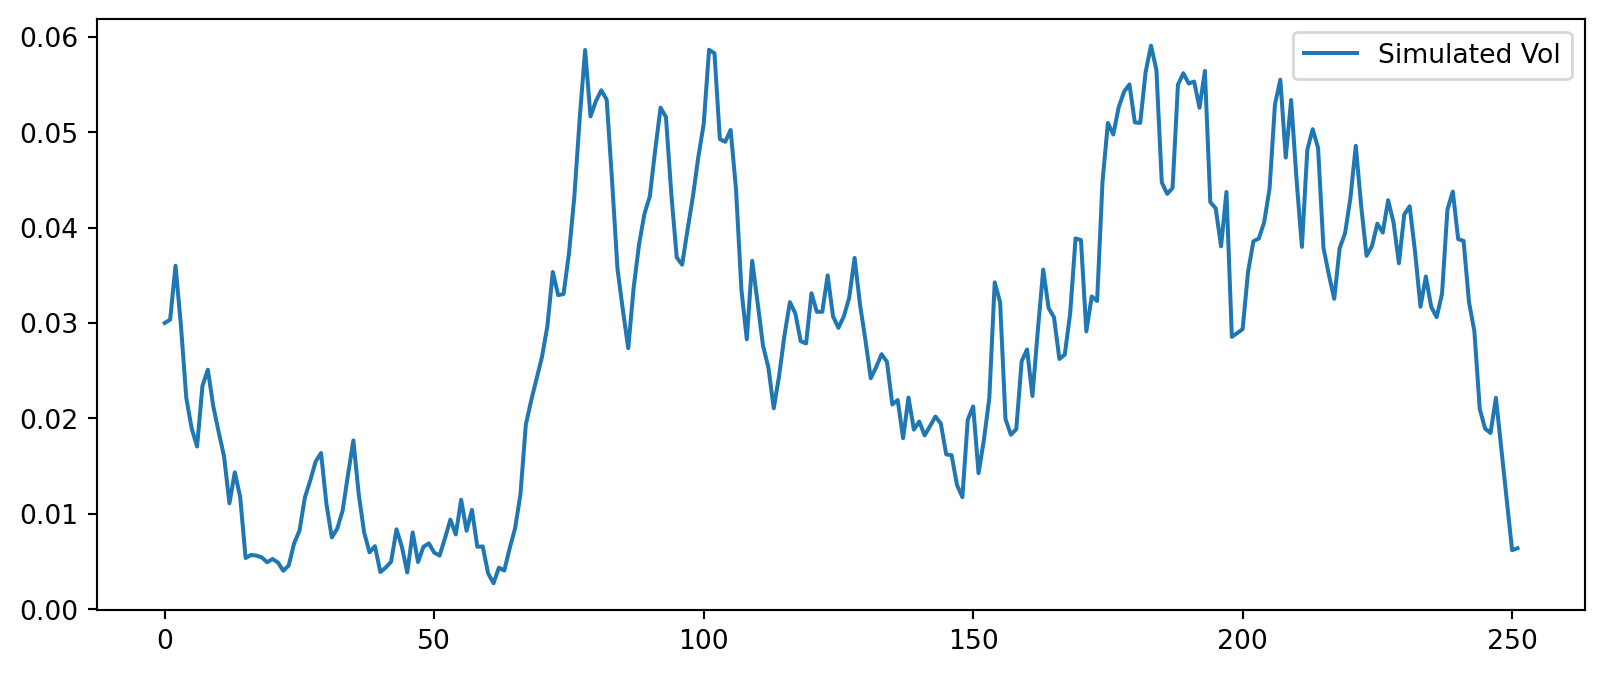

In [5]:
plot_data([v],["Simulated Vol"])

## Application des filtres bootstrap et APF

En considérant la formule théorique de $E(v_t|v_{t-1})$ du théorème \cite{E_condi}, utilisée dans le filtre APF, on constate que le filtre Bootstrap a de meilleures performances sur la prédiction des prix du call. Toutefois, ces performances sont du même ordre de grandeur.

En pratique, $E(v_t|v_{t-1})$ est approximée par $|v_{t-1} + \lambda \Delta(\bar{v}-v_{t-1})|$. En effet, en absence de modification du schéma de discrétisation, $E(v_t|v_{t-1}) = v_{t-1} + \lambda \Delta(\bar{v}-v_{t-1})$. Et donc, pour s'assurer de la positivité de la volatilité, on applique la valeur absolue. 
Avec cette paramétrisation, l'APF a de meilleures performances que le Bootstrap.

In [6]:
M= 5
boot_vol = Bootstrap_Heston(C, S, K, tau, r, lamda, v_bar, rho, sigma, eta, M=M)
apf_vol = APF(C, S, K, tau, r, lamda, v_bar, rho, sigma, eta, M=M)
apf_modif_vol = APF_modified(C, S, K, tau, r, lamda, v_bar, rho, sigma, eta, M=M)

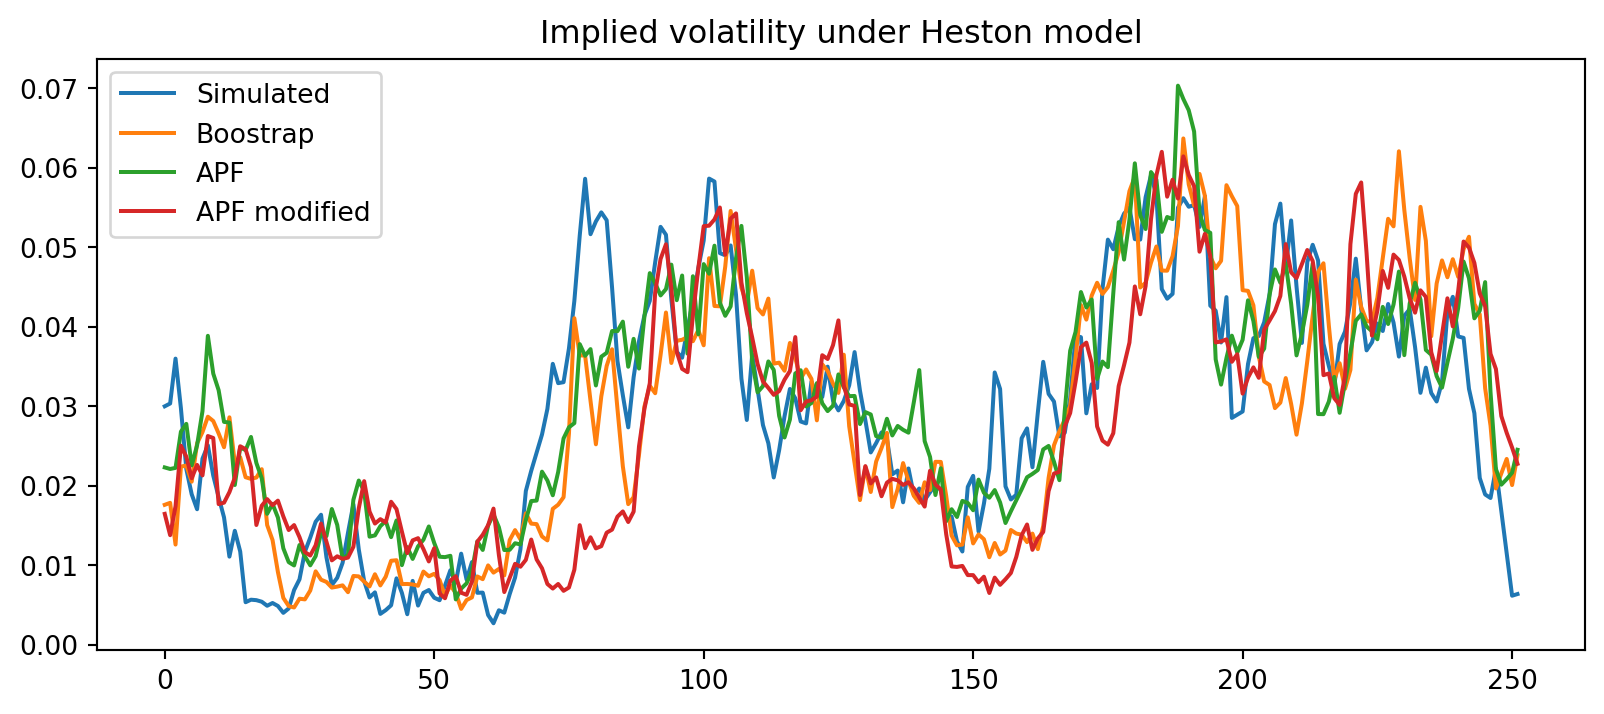

In [7]:
plot_data([v, boot_vol, apf_vol, apf_modif_vol],["Simulated", "Boostrap", "APF", "APF modified"], title = "Implied volatility under Heston model")

In [8]:
C_pred_bootsrtap = np.array([heston(stock_price = S[t],
                         initial_vol = boot_vol[t],
                         kappa = lamda,
                         theta = v_bar, 
                         lambd = eta, 
                         rho = rho, 
                         r = r, 
                         T = tau,
                         K = K) for t in range(len(S))])

C_pred_apf = np.array([heston(stock_price = S[t],
                         initial_vol = apf_vol[t],
                         kappa = lamda,
                         theta = v_bar, 
                         lambd = eta, 
                         rho = rho, 
                         r = r, 
                         T = tau,
                         K = K) for t in range(len(S))])

C_pred_apf_modif = np.array([heston(stock_price = S[t],
                         initial_vol = apf_modif_vol[t],
                         kappa = lamda,
                         theta = v_bar, 
                         lambd = eta, 
                         rho = rho, 
                         r = r, 
                         T = tau,
                         K = K) for t in range(len(S))])


In [9]:
mse_bootstrap = np.mean((v-boot_vol)**2)
mse_apf = np.mean((v-apf_vol)**2)
mse_apf_modif = np.mean((v-apf_modif_vol)**2)

print("MSE BOOTSTRAP:\t", mse_bootstrap)
print("MSE APF:\t", mse_apf)
print("MSE APF modified:\t", mse_apf_modif)

MSE BOOTSTRAP:	 0.00010316011006338895
MSE APF:	 7.28730339992515e-05
MSE APF modified:	 0.00014568041146781666


In [10]:
mse_bootstrap = np.mean((C-C_pred_bootsrtap)**2)
mse_apf = np.mean((C-C_pred_apf)**2)
mse_apf_modif = np.mean((C-C_pred_apf_modif)**2)

print("MSE BOOTSTRAP:\t", mse_bootstrap)
print("MSE APF:\t", mse_apf)
print("MSE APF modified:\t", mse_apf_modif)

MSE BOOTSTRAP:	 0.11152567490028498
MSE APF:	 0.10800123220975723
MSE APF modified:	 0.1401581419221643


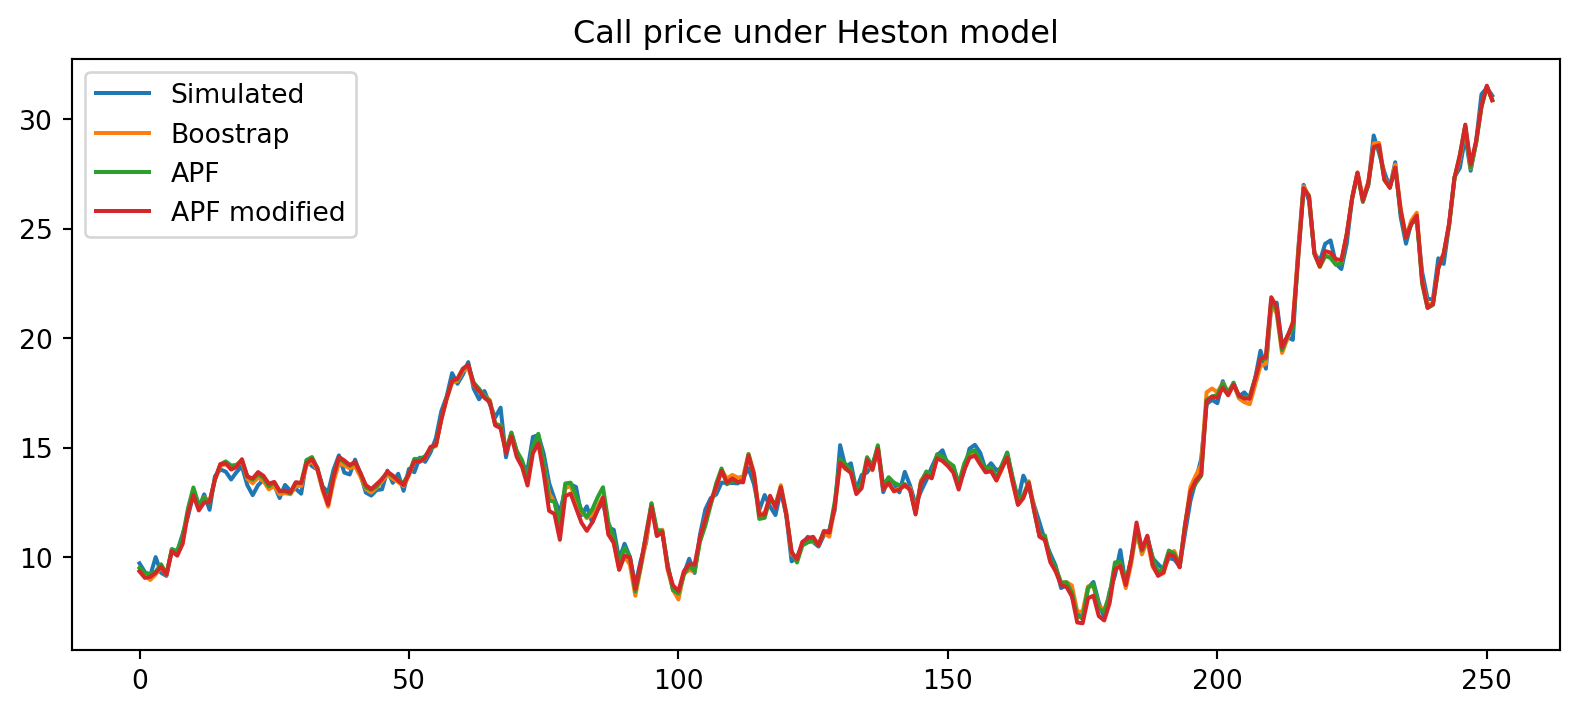

In [11]:
plot_data([C, C_pred_bootsrtap, C_pred_apf, C_pred_apf_modif],["Simulated", "Boostrap", "APF", "APF modified"], title = "Call price under Heston model")

num_particules = [100, 200, 500, 1000]

performances = {"MSE BOOTSTRAP": [],
                "MSE APF": [],
                "MSE APF modified" : []
                }


performances_vol = {"MSE BOOTSTRAP": [],
                "MSE APF": [],
                "MSE APF modified" : []
                }
for M in num_particules:
    boot_vol = Bootstrap_Heston(C, S, K, tau, r, lamda, v_bar, rho, sigma, eta, M=M)
    apf_vol = APF(C, S, K, tau, r, lamda, v_bar, rho, sigma, eta, M=M)
    apf_modif_vol = APF_modified(C, S, K, tau, r, lamda, v_bar, rho, sigma, eta, M=M)

    C_pred_bootsrtap = np.array([heston(stock_price = S[t],
                            initial_vol = boot_vol[t],
                            kappa = lamda,
                            theta = v_bar, 
                            lambd = eta, 
                            rho = rho, 
                            r = r, 
                            T = tau,
                            K = K) for t in range(len(S))])

    C_pred_apf = np.array([heston(stock_price = S[t],
                            initial_vol = apf_vol[t],
                            kappa = lamda,
                            theta = v_bar, 
                            lambd = eta, 
                            rho = rho, 
                            r = r, 
                            T = tau,
                            K = K) for t in range(len(S))])

    C_pred_apf_modif = np.array([heston(stock_price = S[t],
                            initial_vol = apf_modif_vol[t],
                            kappa = lamda,
                            theta = v_bar, 
                            lambd = eta, 
                            rho = rho, 
                            r = r, 
                            T = tau,
                            K = K) for t in range(len(S))])
    
    performances_vol["MSE BOOTSTRAP"].append(np.mean((v-boot_vol)**2))
    performances_vol["MSE APF"].append(np.mean((v-apf_vol)**2))
    performances_vol["MSE APF modified"].append(np.mean((v-apf_modif_vol)**2))

    performances["MSE BOOTSTRAP"].append(np.mean((C-C_pred_bootsrtap)**2))
    performances["MSE APF"].append(np.mean((C-C_pred_apf)**2))
    performances["MSE APF modified"].append(np.mean((C-C_pred_apf_modif)**2))
    
performances = pd.DataFrame(performances)
performances_vol = pd.DataFrame(performances_vol)

#performances.to_csv("peformance.csv", index=False)
#performances_vol.to_csv("peformance_vol.csv", index=False)

In [12]:
#performances = pd.DataFrame(performances)
#performances_vol = pd.DataFrame(performances_vol)

performances = pd.read_csv("peformance.csv")
performances_vol = pd.read_csv("peformance_vol.csv")

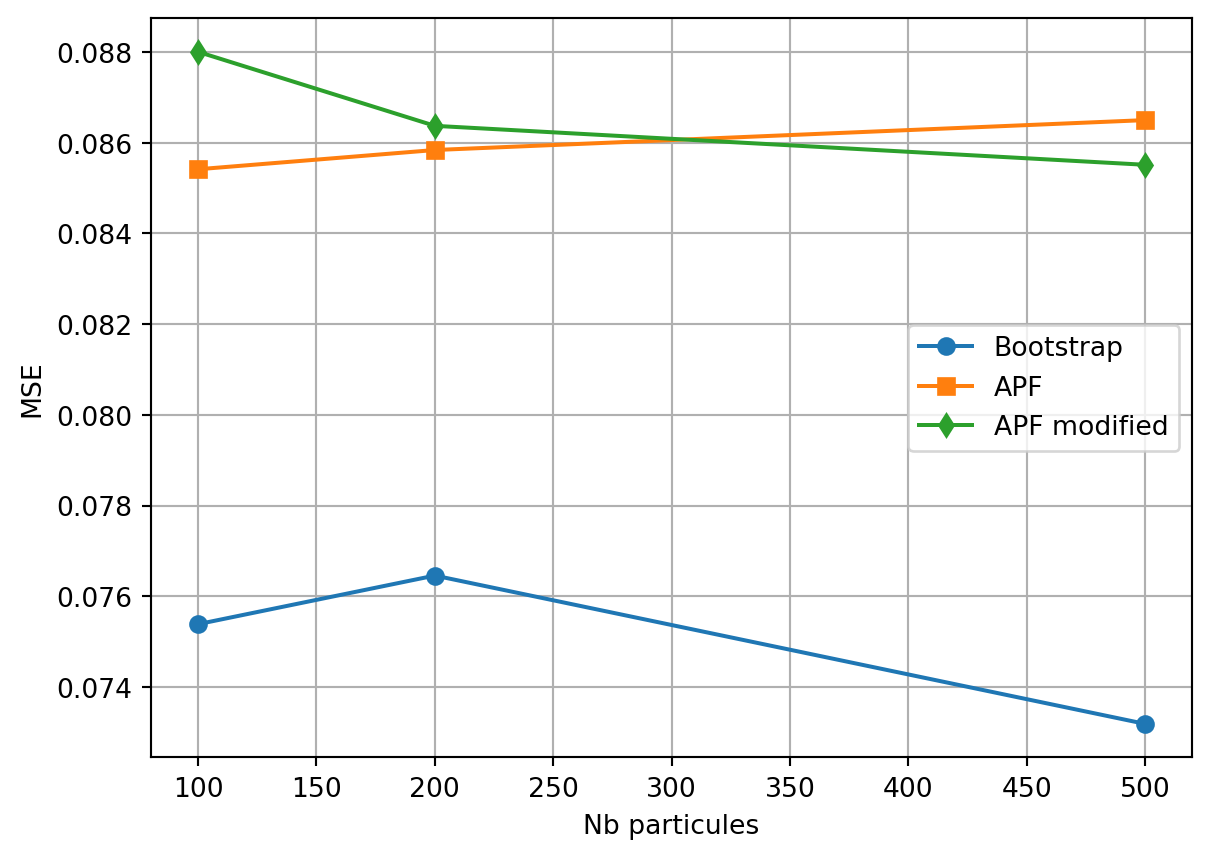

In [13]:
# Labels for different performance metrics
labels = ["Bootstrap", "APF", "APF modified"]
markers = ['o', 's', 'd']  # Different markers for each metric

# Plot each performance column separately
for i in range(performances.shape[1]):
    plt.plot([100,200,500], performances.iloc[:,i], marker=markers[i], linestyle='-', label=labels[i])

# Add grid, legend, and labels
plt.grid(True)
plt.xlabel("Nb particules")
plt.ylabel("MSE")
plt.legend()

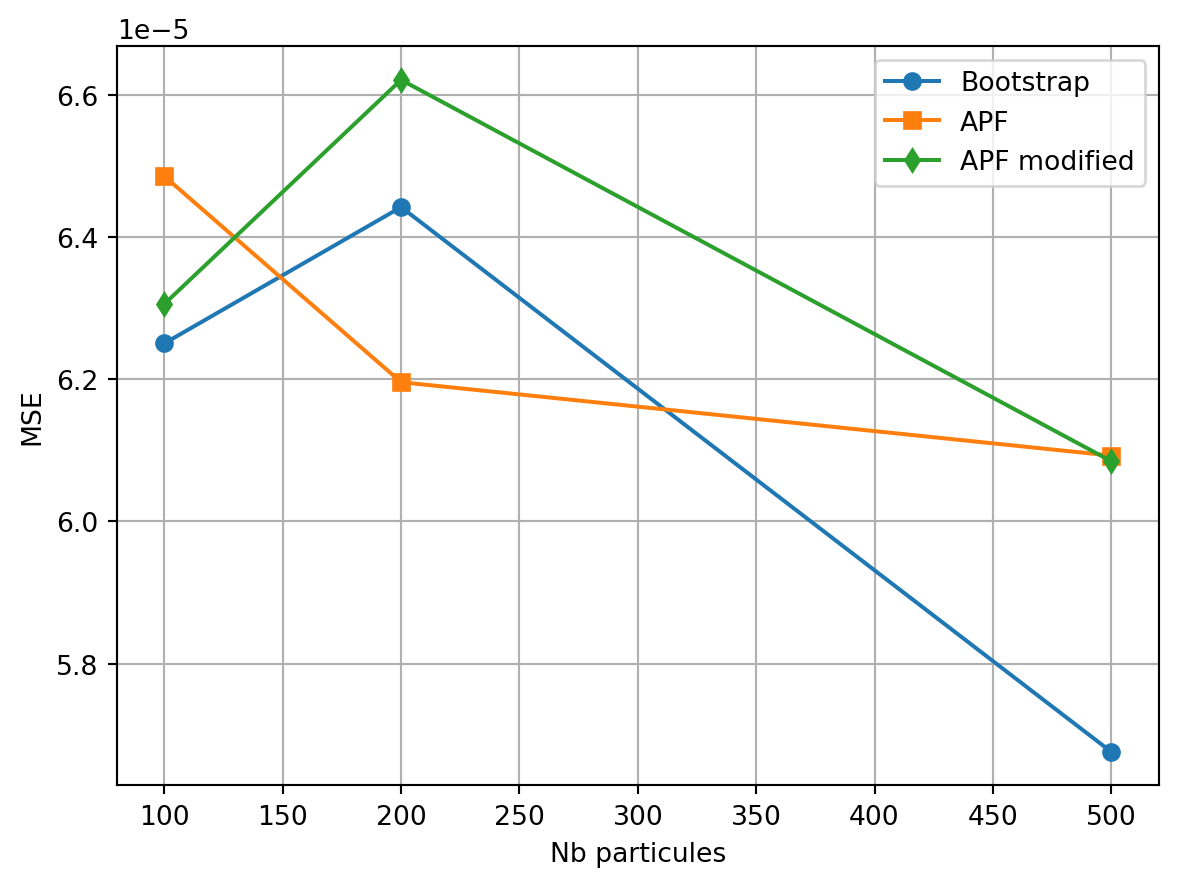

In [14]:
# Labels for different performance metrics
labels = ["Bootstrap", "APF", "APF modified"]
markers = ['o', 's', 'd']  # Different markers for each metric

# Plot each performance column separately
for i in range(performances_vol.shape[1]):
    plt.plot([100,200,500], performances_vol.iloc[:,i], marker=markers[i], linestyle='-', label=labels[i])

# Add grid, legend, and labels
plt.grid(True)
plt.xlabel("Nb particules")
plt.ylabel("MSE")
plt.legend()

# Conclusion

En somme, le filtre APF montrent de meilleurs performances sur la volatilité calibrée par rapport au filtre bootstrap. L'odre de grandeur de ces performances est la même sur les prédictions de prix de call. Toutefois pour un nombre de particules élevé (200), les deux méthodes ont des performances quasi-similaires sur les prix de call.
Deux éléments retiennent l'attention
\begin{itemize}
    \item Une inversion de l'ordre des performances lorsque l'on évalue le MSE sur la vol calibré ou sur les call. Ceci peut s'expliquer par le bruit bruit introduit dans les prix de call.
    
    \item La calibration est réalisée, ceteris paridus. Les paramètre statics n'apportent pas d'information supplémentaire. Dans la pratique on doit calibrer les paramètres du modèle, ce qui peut se faire simultanément avec la calibration de la vol et ainsi permettre de mieux évaluer les performances de ces deux méthodes.
\end{itemize}

# Annexes
Soit $Z\sim \mathcal{N}(m,\sigma^2)$ 

$$
    P[|Z|\leq x] &= P[-x \leq Z\leq x] \\
                 &= P[Z\leq x] - P[Z\leq -x] \\
                 &= P\left[\dfrac{(Z - m)}{\sigma}\leq \dfrac{(x-m)}{\sigma}\right] - P\left[\dfrac{(Z - m)}{\sigma}\leq -\dfrac{(x+m)}{\sigma}\right] \\
                 &= \Phi \left(\dfrac{(x-m)}{\sigma}\right) - \Phi \left(-\dfrac{(x+m)}{\sigma}\right)
$$
 Ainsi

$$
    f_{|Z|}(x) &= \dfrac{1}{\sigma}(\phi\left(\dfrac{(x-m)}{\sigma}\right) + \phi\left(-\dfrac{(x+m)}{\sigma})\right)\\
               &=  \frac{1}{\sigma \sqrt{2\pi} } \left( \exp\left(-\frac{(x-\mu)^2}{2\sigma^2} \right) + \exp\left(-\frac{(x+\mu)^2}{2\sigma^2} \right) \right) \mathbb{1}_{x \geq 0}
$$
On commence par remarquer que pour tout réel $m$ on a:

$$
\int_{0}^{+\infty}x\frac{1}{\sigma \sqrt{2\pi} }  \exp\left(-\frac{(x-m)^2}{2\sigma^2} \right) dx 
    &= \int_{-\frac{m}{\sigma}}^{+\infty} (\sigma u +m) \frac{1}{ \sqrt{2\pi} }  \exp\left(-\frac{u^2}{2} \right) du \\
    &= \int_{-\frac{m}{\sigma}}^{+\infty} \sigma u \frac{1}{ \sqrt{2\pi} }  \exp\left(-\frac{u^2}{2} \right) du
    + \int_{-\frac{m}{\sigma}}^{+\infty} m \frac{1}{ \sqrt{2\pi} }  \exp\left(-\frac{u^2}{2} \right) du\\
    &= \sigma \frac{1}{ \sqrt{2\pi} }  \exp\left(-\frac{m^2}{\sigma^2} \right) 
    + m(1-\Phi(\frac{m}{\sigma}))
$$

$$
    E(|Z|) &= \int_{-\infty}^{+\infty}xf_{|Z|}(x)dx\\
           &= \int_{-\infty}^{+\infty}x\frac{1}{\sigma \sqrt{2\pi} } \left( \exp\left(-\frac{(x-\mu)^2}{2\sigma^2} \right) + \exp\left(-\frac{(x+\mu)^2}{2\sigma^2} \right) \right) \mathbb{1}_{x \geq 0}dx\\
           &= \sigma \frac{1}{ \sqrt{2\pi} }  \exp\left(-\frac{\mu^2}{\sigma^2} \right) + \mu(1-\Phi(-\frac{\mu}{\sigma}))
           + \sigma \frac{1}{ \sqrt{2\pi} }  \exp\left(-\frac{\mu^2}{\sigma^2} \right) 
            - \mu(1-\Phi(\frac{\mu}{\sigma})) \text{,  d'après la remarque }\\
           &= \sigma \frac{2}{ \sqrt{2\pi} }  \exp\left(-\frac{\mu^2}{\sigma^2} \right) + \mu(1-\Phi(-\frac{\mu}{\sigma}))
           +  - \mu \Phi(-\frac{\mu}{\sigma})\\
           &= \sigma \sqrt{\frac{2}{ \pi} }  \exp\left(-\frac{\mu^2}{\sigma^2} \right) + \mu(1-2\Phi(-\frac{\mu}{\sigma}))
$$